In [ ]:
##GOKUL T##
import numpy as np

# Step activation function
def step_function(x):
    return 1 if x >= 0 else 0


# Single Layer Perceptron
def perceptron(X, y, learning_rate=0.1, epochs=10):

    # Initialize weights and bias
    weights = np.zeros(X.shape[1])
    bias = 0

    for epoch in range(epochs):
        total_error = 0

        for i in range(len(X)):

            # Calculate weighted sum
            weighted_sum = np.dot(X[i], weights) + bias

            # Apply step activation
            prediction = step_function(weighted_sum)

            # Calculate error
            error = y[i] - prediction

            # Update weights and bias
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

            total_error += abs(error)

        print("Epoch:", epoch + 1,
              "Error:", total_error,
              "Weights:", weights,
              "Bias:", bias)

        # Stop if no error
        if total_error == 0:
            break

    return weights, bias


# ---------------- AND Gate ----------------
X_AND = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_AND = np.array([0, 0, 0, 1])

print("\nAND Gate")
weights, bias = perceptron(X_AND, y_AND)


print("\nAND Predictions:")
for x in X_AND:
    prediction = step_function(np.dot(x, weights) + bias)
    print(x, "->", prediction)


# ---------------- OR Gate ----------------
y_OR = np.array([0, 1, 1, 1])

print("\nOR Gate")
weights, bias = perceptron(X_AND, y_OR)


print("\nOR Predictions:")
for x in X_AND:
    prediction = step_function(np.dot(x, weights) + bias)
    print(x, "->", prediction)


# ---------------- NOT Gate ----------------
X_NOT = np.array([
    [0],
    [1]
])

y_NOT = np.array([1, 0])

print("\nNOT Gate")
weights, bias = perceptron(X_NOT, y_NOT)


print("\nNOT Predictions:")
for x in X_NOT:
    prediction = step_function(np.dot(x, weights) + bias)
    print(x, "->", prediction)


AND Gate
Epoch: 1 Error: 2 Weights: [0.1 0.1] Bias: 0.0
Epoch: 2 Error: 3 Weights: [0.2 0.1] Bias: -0.1
Epoch: 3 Error: 3 Weights: [0.2 0.1] Bias: -0.20000000000000004
Epoch: 4 Error: 0 Weights: [0.2 0.1] Bias: -0.20000000000000004

AND Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

OR Gate
Epoch: 1 Error: 2 Weights: [0.  0.1] Bias: 0.0
Epoch: 2 Error: 2 Weights: [0.1 0.1] Bias: 0.0
Epoch: 3 Error: 1 Weights: [0.1 0.1] Bias: -0.1
Epoch: 4 Error: 0 Weights: [0.1 0.1] Bias: -0.1

OR Predictions:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

NOT Gate
Epoch: 1 Error: 1 Weights: [-0.1] Bias: -0.1
Epoch: 2 Error: 1 Weights: [-0.1] Bias: 0.0
Epoch: 3 Error: 0 Weights: [-0.1] Bias: 0.0

NOT Predictions:
[0] -> 1
[1] -> 0


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# 2. Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFirst 5 rows:")
print(X.head())


# 3. Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# 4. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 5. Build MLP Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])


# 6. Display Model Architecture
model.summary()


# 7. Compile the Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# 8. Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# 9. Evaluate the Model
loss, mae = model.evaluate(X_test, y_test, verbose=0)

print("\nModel Evaluation")
print("-----------------------")
print("Test MSE:", loss)
print("Test MAE:", mae)


# 10. Make Predictions
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

print("\nFirst 10 Predictions")
print("-----------------------")

for i in range(10):
    print("Actual:", y_test.iloc[i],
          "Predicted:", y_pred[i])


# 11. Calculate Performance Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nPerformance Metrics")
print("-----------------------")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)




Dataset loaded successfully!
Number of samples: 20640
Number of features: 8

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Training samples: 16512
Testing samples: 4128


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9298 - mae: 0.6627 - val_loss: 0.4587 - val_mae: 0.4867
Epoch 2/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3943 - mae: 0.4477 - val_loss: 0.4019 - val_mae: 0.4585
Epoch 3/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3632 - mae: 0.4292 - val_loss: 0.3724 - val_mae: 0.4325
Epoch 4/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3495 - mae: 0.4167 - val_loss: 0.3722 - val_mae: 0.4326
Epoch 5/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3337 - mae: 0.4072 - val_loss: 0.3728 - val_mae: 0.4329
Epoch 6/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3291 - mae: 0.4049 - val_loss: 0.3429 - val_mae: 0.4131
Epoch 7/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3176 - mae: 0.3943 - val_loss: 0.3496 - val_mae: 0.4184
Epoch 8/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3104 - mae: 0.3887 - val_loss: 0.3482 - val_mae: 0.3988
Epoch 9/25
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [6]:

import pandas as pd
import numpy as np

cancer = pd.read_csv('/content/housing.csv')

cancer.head()

cancer.shape

# Separate X and Y
x = cancer.drop('ocean_proximity', axis=1)
y = cancer['ocean_proximity']


# Handle missing values
x['total_bedrooms'] = x['total_bedrooms'].fillna(
    x['total_bedrooms'].median()
)


# Min-Max Scaling
from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()

x_scale = min_max_scaler.fit_transform(x)

print(x_scale)


# Label Encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


# Train Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scale,
    y,
    test_size=0.20,
    random_state=0
)


# Neural Network
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

model.add(
    Dense(
        32,
        activation='relu',
        input_dim=9
    )
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(
        5,
        activation='softmax'
    )
)


# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Train Model
model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32
)


# Prediction
y_pred = model.predict(x_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

print(y_pred)


# Actual vs Predicted
print(
    np.column_stack(
        (y_pred, y_test)
    )
)


# Accuracy
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


# Confusion Matrix
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

[[0.21115538 0.5674814  0.78431373 ... 0.02055583 0.53966842 0.90226638]
 [0.21215139 0.565356   0.39215686 ... 0.18697583 0.53802706 0.70824656]
 [0.21015936 0.5642933  1.         ... 0.02894261 0.46602805 0.69505074]
 ...
 [0.31175299 0.73219979 0.31372549 ... 0.07104095 0.08276438 0.15938285]
 [0.30179283 0.73219979 0.33333333 ... 0.05722743 0.09429525 0.14371281]
 [0.30976096 0.72582359 0.29411765 ... 0.08699227 0.13025338 0.15340349]]


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6559 - loss: 0.9387
Epoch 2/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7434 - loss: 0.6798
Epoch 3/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7820 - loss: 0.5853
Epoch 4/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8065 - loss: 0.5212
Epoch 5/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8216 - loss: 0.4741
Epoch 6/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8342 - loss: 0.4338
Epoch 7/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8433 - loss: 0.4030
Epoch 8/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8519 - loss: 0.3755
Epoch 9/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8596 - loss: 0.3522
Epoch 10/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8654 - loss: 0.3362
Epoch 11/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8709 - loss: 0.3201
Epoch 12/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Trial 10 Complete [00h 00m 04s]
val_accuracy: 0.625

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 38s

Best Hyperparameters
----------------------------
Number of hidden layers: 3
Number of neurons: 112
Dropout rate: 0.30000000000000004
Optimizer: adam
Learning rate: 0.001

Best Model Architecture


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 112)            │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 112)            │        12,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 112)            │        12,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           339 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,211 (102.39 KB)

 Trainable params: 26,211 (102.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9271 - loss: 0.1415 - val_accuracy: 0.9583 - val_loss: 0.1169
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9479 - loss: 0.1597 - val_accuracy: 0.9583 - val_loss: 0.1057
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9583 - loss: 0.1424 - val_accuracy: 1.0000 - val_loss: 0.0888
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9583 - loss: 0.1237 - val_accuracy: 1.0000 - val_loss: 0.0745
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9479 - loss: 0.1300 - val_accuracy: 1.0000 - val_loss: 0.0731
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9688 - loss: 0.1035 - val_accuracy: 1.0000 - val_loss: 0.0545
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9792 - loss: 0.0965 - val_accuracy: 1.0000 - val_loss: 0.0530
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9583 - loss: 0.0902 - val_accuracy: 1.0000 - val_loss: 0.0475


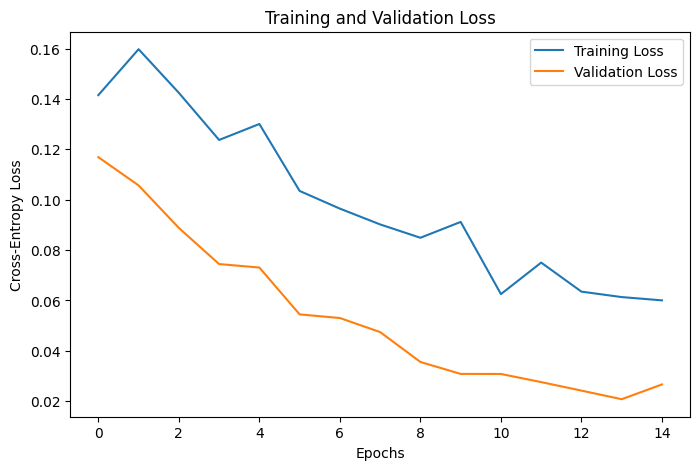

In [ ]:
!pip install keras-tuner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

import keras_tuner as kt


# ============================================================
# 2. Load Iris Dataset
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Input shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)


# ============================================================
# 3. Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 4. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# 5. Define Hyperparameter Model
# ============================================================

def build_model(hp):

    model = Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        'num_layers',
        min_value=1,
        max_value=3,
        step=1
    )

    # First hidden layer
    units = hp.Int(
        'units',
        min_value=16,
        max_value=128,
        step=16
    )

    model.add(
        Dense(
            units=units,
            activation='relu',
            input_shape=(4,)
        )
    )

    # Additional hidden layers
    for i in range(num_layers - 1):

        model.add(
            Dense(
                units=units,
                activation='relu'
            )
        )

    # Dropout rate
    dropout_rate = hp.Float(
        'dropout_rate',
        min_value=0.0,
        max_value=0.5,
        step=0.1
    )

    model.add(Dropout(dropout_rate))

    # Output layer
    model.add(
        Dense(
            3,
            activation='softmax'
        )
    )

    # Optimizer
    optimizer_name = hp.Choice(
        'optimizer',
        values=['adam', 'sgd']
    )

    # Learning rate
    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.001, 0.01, 0.0001]
    )

    if optimizer_name == 'adam':

        optimizer = Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ============================================================
# 6. Create Keras Tuner
# ============================================================

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='keras_tuner',
    project_name='iris_mlp'
)


# ============================================================
# 7. Display Search Space
# ============================================================

tuner.search_space_summary()


# ============================================================
# 8. Hyperparameter Search
# ============================================================

tuner.search(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=16,
    verbose=1
)


# ============================================================
# 9. Display Best Hyperparameters
# ============================================================

best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("\nBest Hyperparameters")
print("----------------------------")

print(
    "Number of hidden layers:",
    best_hps.get('num_layers')
)

print(
    "Number of neurons:",
    best_hps.get('units')
)

print(
    "Dropout rate:",
    best_hps.get('dropout_rate')
)

print(
    "Optimizer:",
    best_hps.get('optimizer')
)

print(
    "Learning rate:",
    best_hps.get('learning_rate')
)


# ============================================================
# 10. Get Best Model
# ============================================================

best_model = tuner.get_best_models(
    num_models=1
)[0]

print("\nBest Model Architecture")
best_model.summary()


# ============================================================
# 11. Train Best Model
# ============================================================

history = best_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


# ============================================================
# 12. Evaluate Model
# ============================================================

loss, accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nModel Evaluation")
print("----------------------------")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# ============================================================
# 13. Make Predictions
# ============================================================

y_probability = best_model.predict(X_test)

y_pred = np.argmax(
    y_probability,
    axis=1
)


# ============================================================
# 14. Calculate Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nFinal Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# ============================================================
# 15. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 16. Classification Report
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)




plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

